# Question 2: Customer Lifetime Value and Retention

## Objective
Understand customer lifetime value distribution and determine whether the 137% YoY growth from Question 1 is driven by new customer acquisition or by existing customers buying more.

## Approach
- Joined orders, order_items, and customers using customer_unique_id (not customer_id) to correctly identify unique people
- Built customer-level summary with revenue, order count, tenure, AOV, and state per person
- Calculated CLV distribution and segmented customers into 5 spending tiers
- Performed Pareto analysis at the customer level
- Built cohort retention matrix tracking each cohort over up to 12 months
- Split monthly revenue into new vs returning customer contributions

## Key Findings

### Finding 1: Repeat customer behavior is extremely rare
- 96.9% of customers placed exactly one order across the entire 2-year period
- Only 2.8% placed exactly two orders, and 0.3% placed three or more
- The highest-frequency customer placed just 16 orders across two years
- This is dramatically lower than typical e-commerce repeat rates of 20 to 40%

### Finding 2: Growth is almost entirely driven by new customer acquisition
- New customers contributed 97-99% of revenue in every single month from 2017 onwards
- Returning customer revenue share peaked at just 3.0% (June 2018) and averaged around 1.8%
- The 137% YoY growth seen in Question 1 is therefore a new-acquisition story, not a retention story
- This creates significant strategic risk: if acquisition slows, growth halts immediately

### Finding 3: CLV distribution is right-skewed with a meaningful tail
- Median CLV is 89.90 BRL (the typical customer)
- Mean CLV is 142.44 BRL, pulled higher by big spenders
- Standard deviation of 217.66 BRL confirms the skew
- The top customer spent 13,440 BRL in a single 8-item order, suggesting some B2B-style buyers exist
- 75th percentile is 155 BRL, so even the upper-mid customer is a modest spender

### Finding 4: Customer revenue concentration is moderate but real
- Top 1% of customers (958 people) drive 11.55% of revenue
- Top 5% drive 29.26%
- Top 10% drive 41.24%
- Top 20% drive 56.76%
- Less concentrated than typical SaaS (where top 10% often drives 70%+) but still material

### Finding 5: Mid and high-value customers are where most revenue lives
Customer segments by CLV reveal the strategic targeting opportunity:
- Low (under 50 BRL): 28.9% of customers, only 6.5% of revenue
- Mid (50-150 BRL): 45.3% of customers, 30.0% of revenue (the largest segment)
- High (150-500 BRL): 21.8% of customers, 37.6% of revenue (the highest-value segment by total revenue)
- Premium (500-1000 BRL): 2.9% of customers, 14.2% of revenue
- VIP (1000+ BRL): 1.0% of customers, 11.7% of revenue

The High segment (150-500 BRL) is the workhorse: only 21.8% of the customer base but 37.6% of revenue.

### Finding 6: Retention collapses immediately after period 1
Average retention curve across all cohorts:
- Period 0 (first month): 100% by definition
- Period 1 (next month): 5.20%
- Period 2: 0.34%
- Period 3: 0.25%
- Period 6: 0.26%
- Period 12: 0.22%

The pattern is striking. Around 5% of customers come back in the immediately following month, then drop to under 0.5% from period 2 onwards. This is not a typical "decay curve" where retention slowly drops over time. It's a cliff, then flatline. Suggests customers who repeat tend to do so quickly (likely returning for a related second item) or never.

### Finding 7: Top spenders are big-ticket one-time buyers, not loyalists
Looking at the top 10 customers by revenue:
- Highest spender: 13,440 BRL across a single 8-item order
- 9 of the top 10 placed only 1 order
- Only 1 of the top 10 (number 2 on the list) placed 2 orders
- Tenure days for all top 10 customers is 0

This means the highest-value customers are not loyal repeat buyers. They're people who came in once, bought a lot, and left. Possibly small business owners or gift buyers.

## Limitations
- Cannot distinguish between active churn (customer chose to leave) and natural one-time purchases (customer simply didn't need anything else)
- 2-year observation window may be too short to capture longer purchase cycles for categories like furniture or appliances
- 2016 cohorts have too few customers (3 in Sept 2016, 1 in Dec 2016) for reliable retention analysis
- No data on marketing campaigns, email engagement, or product changes that might explain retention patterns
- Brazilian e-commerce culture may favor cross-marketplace comparison shopping, which would structurally limit single-marketplace retention

## Strategic Implications
This analysis reframes the entire Olist growth story:

1. The 137% growth in 2018 is impressive but entirely acquisition-dependent
2. Customer economics are tight: with median CLV at 89.90 BRL, customer acquisition cost must stay well below this number
3. There is substantial untapped retention upside. Moving period 1 retention from 5.20% to 8-10% would meaningfully accelerate growth without increasing acquisition spend
4. The High CLV segment (21.8% of customers, 37.6% of revenue) is the most efficient target for retention efforts
5. Big-ticket one-time buyers (Premium and VIP segments) likely need a different strategy than repeat-focused programs. These customers may respond to referral programs more than email reactivation
6. Strategic growth categories from Question 1 (health_beauty, watches_gifts, sports_leisure) should be evaluated for natural repeat purchase potential

## Recommendations for Q4
1. Launch a 30-60-90 day post-purchase reactivation program targeting High and Premium segments
2. Set a measurable retention KPI: lift period 1 retention from 5.20% to 7% by end of Q1 2019
3. Build a referral incentive program specifically for VIP customers (top 1%), since they're already willing to make large purchases
4. Investigate why retention drops from 5.20% at period 1 to 0.34% at period 2. Are customers buying complementary items in month 1 (e.g., a phone, then a phone case), then not finding ongoing reasons to return?
5. Evaluate whether the marketplace category mix favors one-time purchases (furniture, appliances) over repeat purchases (consumables, fashion). Strategic categories that drive natural repeat purchase frequency should get inventory investment

## Next Analysis
Operations and delivery. The remaining critical question: are delivery problems killing the repeat purchase rate? If late or poor deliveries are causing customers not to return, that's an operational lever that retention programs alone cannot fix. We need to understand if the retention floor is operationally driven before we invest in marketing-led retention.

In [1]:
# E-commerce Sales Analysis — Day 4: Customer Lifetime Value & Retention
# Author: Rohan Vishwakarma

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

DATA_DIR = Path('../data/raw')

# Load the tables we need
orders = pd.read_csv(DATA_DIR / 'olist_orders_dataset.csv')
order_items = pd.read_csv(DATA_DIR / 'olist_order_items_dataset.csv')
customers = pd.read_csv(DATA_DIR / 'olist_customers_dataset.csv')

# Convert dates
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

print("Data loaded ✅")
print(f"orders: {orders.shape}")
print(f"order_items: {order_items.shape}")
print(f"customers: {customers.shape}")

Data loaded ✅
orders: (99441, 8)
order_items: (112650, 7)
customers: (99441, 5)


In [2]:
# Critical: understand the difference between customer_id and customer_unique_id

print("Customers table columns:")
print(customers.columns.tolist())
print(f"\nTotal rows in customers: {len(customers):,}")
print(f"Unique customer_id: {customers['customer_id'].nunique():,}")
print(f"Unique customer_unique_id: {customers['customer_unique_id'].nunique():,}")

print(f"\nDifference: {customers['customer_id'].nunique() - customers['customer_unique_id'].nunique():,}")
print("→ This difference represents repeat customers (same person, different orders)")

Customers table columns:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

Total rows in customers: 99,441
Unique customer_id: 99,441
Unique customer_unique_id: 96,096

Difference: 3,345
→ This difference represents repeat customers (same person, different orders)


In [3]:
# Join orders + order_items + customers to get one row per order item
# with customer_unique_id attached
customer_orders = (
    orders
    .merge(order_items, on='order_id', how='inner')
    .merge(customers[['customer_id', 'customer_unique_id', 'customer_state']], 
           on='customer_id', how='left')
)

print(f"Combined dataset: {customer_orders.shape}")
print(f"Unique people: {customer_orders['customer_unique_id'].nunique():,}")
print(f"Unique orders: {customer_orders['order_id'].nunique():,}")
print(f"Order items: {len(customer_orders):,}")

Combined dataset: (112650, 16)
Unique people: 95,420
Unique orders: 98,666
Order items: 112,650


In [4]:
# Build customer-level metrics
customer_summary = (
    customer_orders
    .groupby('customer_unique_id')
    .agg(
        total_revenue=('price', 'sum'),
        total_freight=('freight_value', 'sum'),
        num_orders=('order_id', 'nunique'),
        num_items=('order_item_id', 'count'),
        first_purchase=('order_purchase_timestamp', 'min'),
        last_purchase=('order_purchase_timestamp', 'max'),
        customer_state=('customer_state', 'first'),
    )
    .round(2)
)

# Calculate tenure (days between first and last purchase)
customer_summary['tenure_days'] = (
    customer_summary['last_purchase'] - customer_summary['first_purchase']
).dt.days

# Calculate AOV (Average Order Value) per customer
customer_summary['avg_order_value'] = (
    customer_summary['total_revenue'] / customer_summary['num_orders']
).round(2)

print(f"Customer summary: {customer_summary.shape}")
print("\nFirst 5 customers:")
customer_summary.head()

Customer summary: (95420, 9)

First 5 customers:


/var/folders/js/d0pfw3yj5t50dtjb07h1b8y80000gn/T/ipykernel_19597/2720552233.py:14: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .round(2)


,total_revenue,total_freight,num_orders,num_items,first_purchase,last_purchase,customer_state,tenure_days,avg_order_value
customer_unique_id,,,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,129.90,12.00,1,1,2018-05-10 10:56:27,2018-05-10 10:56:27,SP,0,129.90
0000b849f77a49e4a4ce2b2a4ca5be3f,18.90,8.29,1,1,2018-05-07 11:11:27,2018-05-07 11:11:27,SP,0,18.90
0000f46a3911fa3c0805444483337064,69.00,17.22,1,1,2017-03-10 21:05:03,2017-03-10 21:05:03,SC,0,69.00
0000f6ccb0745a6a4b88665a16c9f078,25.99,17.63,1,1,2017-10-12 20:29:41,2017-10-12 20:29:41,PA,0,25.99
0004aac84e0df4da2b147fca70cf8255,180.00,16.89,1,1,2017-11-14 19:45:42,2017-11-14 19:45:42,SP,0,180.00


In [5]:
# Summary statistics on customer lifetime value (CLV = total_revenue per customer)
print("CUSTOMER LIFETIME VALUE DISTRIBUTION (in BRL)")
print("=" * 60)
print(customer_summary['total_revenue'].describe().round(2))

print(f"\nTotal customers: {len(customer_summary):,}")
print(f"Total revenue: {customer_summary['total_revenue'].sum():,.2f} BRL")
print(f"Average CLV: {customer_summary['total_revenue'].mean():.2f} BRL")
print(f"Median CLV: {customer_summary['total_revenue'].median():.2f} BRL")

CUSTOMER LIFETIME VALUE DISTRIBUTION (in BRL)
count    95420.00
mean       142.44
std        217.66
min          0.85
25%         47.90
50%         89.90
75%        155.00
max      13440.00
Name: total_revenue, dtype: float64

Total customers: 95,420
Total revenue: 13,591,643.70 BRL
Average CLV: 142.44 BRL
Median CLV: 89.90 BRL


In [6]:
# How many orders does each customer place?
print("ORDERS PER CUSTOMER")
print("=" * 50)
print(customer_summary['num_orders'].value_counts().sort_index().head(10))

print(f"\n% of customers with exactly 1 order: {(customer_summary['num_orders'] == 1).mean() * 100:.1f}%")
print(f"% of customers with 2+ orders: {(customer_summary['num_orders'] >= 2).mean() * 100:.1f}%")
print(f"% of customers with 3+ orders: {(customer_summary['num_orders'] >= 3).mean() * 100:.1f}%")

ORDERS PER CUSTOMER
num_orders
1     92507
2      2673
3       192
4        29
5         9
6         5
7         3
9         1
16        1
Name: count, dtype: int64

% of customers with exactly 1 order: 96.9%
% of customers with 2+ orders: 3.1%
% of customers with 3+ orders: 0.3%


In [7]:
# Segment customers by CLV bucket
def clv_bucket(value):
    if value < 50:
        return '1. Low (<50)'
    elif value < 150:
        return '2. Mid (50-150)'
    elif value < 500:
        return '3. High (150-500)'
    elif value < 1000:
        return '4. Premium (500-1000)'
    else:
        return '5. VIP (1000+)'

customer_summary['clv_segment'] = customer_summary['total_revenue'].apply(clv_bucket)

segment_summary = (
    customer_summary
    .groupby('clv_segment')
    .agg(
        num_customers=('total_revenue', 'count'),
        total_revenue=('total_revenue', 'sum'),
        avg_clv=('total_revenue', 'mean'),
    )
    .round(2)
)

segment_summary['pct_customers'] = (segment_summary['num_customers'] / len(customer_summary) * 100).round(1)
segment_summary['pct_revenue'] = (segment_summary['total_revenue'] / segment_summary['total_revenue'].sum() * 100).round(1)

print("CUSTOMER SEGMENTATION BY CLV")
print("=" * 70)
print(segment_summary)

CUSTOMER SEGMENTATION BY CLV
                       num_customers  total_revenue  avg_clv  pct_customers  pct_revenue
clv_segment                                                                             
1. Low (<50)                   27585      879441.86    31.88           28.9          6.5
2. Mid (50-150)                43226     4081771.35    94.43           45.3         30.0
3. High (150-500)              20832     5115615.75   245.57           21.8         37.6
4. Premium (500-1000)           2799     1924911.46   687.71            2.9         14.2
5. VIP (1000+)                   978     1589903.28  1625.67            1.0         11.7


In [8]:
# Sort customers by revenue, calculate cumulative %
customer_sorted = customer_summary.sort_values('total_revenue', ascending=False).reset_index()
customer_sorted['rank'] = range(1, len(customer_sorted) + 1)
customer_sorted['cumulative_revenue'] = customer_sorted['total_revenue'].cumsum()
total_rev = customer_sorted['total_revenue'].sum()
customer_sorted['cumulative_pct_revenue'] = (customer_sorted['cumulative_revenue'] / total_rev * 100).round(2)
customer_sorted['pct_customers'] = (customer_sorted['rank'] / len(customer_sorted) * 100).round(2)

# Show key Pareto thresholds
print("REVENUE CONCENTRATION BY CUSTOMERS")
print("=" * 60)

thresholds = [1, 5, 10, 20, 50]
for pct in thresholds:
    threshold_row = customer_sorted[customer_sorted['pct_customers'] <= pct].tail(1)
    if len(threshold_row) > 0:
        rev_pct = threshold_row['cumulative_pct_revenue'].iloc[0]
        num_customers = int(threshold_row['rank'].iloc[0])
        print(f"Top {pct}% of customers ({num_customers:,} people) = {rev_pct}% of revenue")

REVENUE CONCENTRATION BY CUSTOMERS
Top 1% of customers (958 people) = 11.55% of revenue
Top 5% of customers (4,775 people) = 29.26% of revenue
Top 10% of customers (9,546 people) = 41.24% of revenue
Top 20% of customers (19,088 people) = 56.76% of revenue
Top 50% of customers (47,714 people) = 83.38% of revenue


In [9]:
# Who are the top 10 customers?
top_10 = customer_sorted.head(10)[
    ['customer_unique_id', 'total_revenue', 'num_orders', 'num_items', 'customer_state', 'tenure_days']
]
print("TOP 10 CUSTOMERS BY REVENUE")
print("=" * 80)
print(top_10.to_string(index=False))

TOP 10 CUSTOMERS BY REVENUE
              customer_unique_id  total_revenue  num_orders  num_items customer_state  tenure_days
0a0a92112bd4c708ca5fde585afaa872        13440.0           1          8             RJ            0
da122df9eeddfedc1dc1f5349a1a690c         7388.0           2          2             RJ            0
763c8b1c9c68a0229c42c9fc6f662b93         7160.0           1          4             ES            0
dc4802a71eae9be1dd28f5d788ceb526         6735.0           1          1             MS            0
459bef486812aa25204be022145caa62         6729.0           1          1             ES            0
ff4159b92c40ebe40454e3e6a7c35ed6         6499.0           1          1             SP            0
4007669dec559734d6f53e029e360987         5934.6           1          6             MG            0
eebb5dda148d3893cdaf5b5ca3040ccb         4690.0           1          1             SP            0
5d0a2980b292d049061542014e8960bf         4599.9           1          2           

In [10]:
# A customer's cohort = the month of their first purchase
customer_orders['order_month'] = customer_orders['order_purchase_timestamp'].dt.to_period('M')

# Find each customer's first purchase month
customer_cohorts = (
    customer_orders
    .groupby('customer_unique_id')['order_month']
    .min()
    .reset_index()
    .rename(columns={'order_month': 'cohort_month'})
)

# Attach cohort back to all orders
customer_orders = customer_orders.merge(customer_cohorts, on='customer_unique_id', how='left')

print(f"Cohort assignment complete ✅")
print(f"\nCustomer count per cohort (first 12 months):")
print(customer_cohorts['cohort_month'].value_counts().sort_index().head(12))

Cohort assignment complete ✅

Customer count per cohort (first 12 months):
cohort_month
2016-09       3
2016-10     305
2016-12       1
2017-01     754
2017-02    1705
2017-03    2595
2017-04    2339
2017-05    3560
2017-06    3114
2017-07    3843
2017-08    4149
2017-09    4090
Freq: M, Name: count, dtype: int64


In [11]:
# Calculate periods since each customer's first purchase
# Period 0 = month they joined, Period 1 = next month, etc.

customer_orders['period_number'] = (
    (customer_orders['order_month'] - customer_orders['cohort_month'])
    .apply(lambda x: x.n if hasattr(x, 'n') else 0)
)

# Sample check
print("Sample data:")
print(customer_orders[
    ['customer_unique_id', 'cohort_month', 'order_month', 'period_number']
].head(10))

Sample data:
                 customer_unique_id cohort_month order_month  period_number
0  7c396fd4830fd04220f754e42b4e5bff      2017-09     2017-10              1
1  af07308b275d755c9edb36a90c618231      2018-07     2018-07              0
2  3a653a41f6f9fc3d2a113cf8398680e8      2018-08     2018-08              0
3  7c142cf63193a1473d2e66489a9ae977      2017-11     2017-11              0
4  72632f0f9dd73dfee390c9b22eb56dd6      2018-02     2018-02              0
5  80bb27c7c16e8f973207a5086ab329e2      2017-07     2017-07              0
6  36edbb3fb164b1f16485364b6fb04c73      2017-04     2017-04              0
7  932afa1e708222e5821dac9cd5db4cae      2017-05     2017-05              0
8  39382392765b6dc74812866ee5ee92a7      2017-01     2017-01              0
9  299905e3934e9e181bfb2e164dd4b4f8      2017-07     2017-07              0


In [12]:
# Count unique customers active in each cohort × period combination
cohort_table = (
    customer_orders
    .groupby(['cohort_month', 'period_number'])['customer_unique_id']
    .nunique()
    .reset_index()
)

# Pivot to a matrix: cohorts as rows, periods as columns
cohort_pivot = cohort_table.pivot(
    index='cohort_month',
    columns='period_number',
    values='customer_unique_id'
)

# Convert to retention percentages (Period 0 = 100% baseline)
cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0) * 100
retention_matrix = retention_matrix.round(2)

# Show first 12 cohorts, first 12 periods
print("COHORT RETENTION MATRIX (% of cohort still active)")
print("=" * 80)
print(retention_matrix.iloc[:12, :12])

COHORT RETENTION MATRIX (% of cohort still active)
period_number     0       1     2     3     4     5     6     7     8     9     10    11
cohort_month                                                                            
2016-09        100.0     NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN
2016-10        100.0     NaN   NaN   NaN   NaN   NaN  0.33   NaN   NaN  0.33   NaN  0.33
2016-12        100.0  100.00   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN
2017-01        100.0    0.40  0.27  0.13  0.40  0.13  0.40  0.13  0.13   NaN  0.40  0.13
2017-02        100.0    0.23  0.29  0.12  0.41  0.12  0.23  0.18  0.12  0.18  0.12  0.29
2017-03        100.0    0.50  0.35  0.39  0.35  0.15  0.15  0.31  0.35  0.08  0.39  0.12
2017-04        100.0    0.60  0.21  0.17  0.34  0.26  0.34  0.30  0.30  0.17  0.26  0.09
2017-05        100.0    0.48  0.48  0.39  0.31  0.34  0.42  0.14  0.25  0.28  0.25  0.34
2017-06        100.0    0.48  0.35  0.39  0.26  0.39  0.39 

In [13]:
# Average retention across all cohorts at each period
avg_retention = retention_matrix.mean(axis=0).round(2)

print("AVERAGE RETENTION CURVE (across all cohorts)")
print("=" * 50)
print(f"Period 0 (acquisition):  {avg_retention[0]:.2f}%")
for period in [1, 2, 3, 6, 12]:
    if period in avg_retention.index:
        print(f"Period {period}: {avg_retention[period]:.2f}%")

AVERAGE RETENTION CURVE (across all cohorts)
Period 0 (acquisition):  100.00%
Period 1: 5.20%
Period 2: 0.34%
Period 3: 0.25%
Period 6: 0.26%
Period 12: 0.22%


In [14]:
# For each order, mark whether the customer's first purchase was that same order
customer_orders['is_new_customer_order'] = (
    customer_orders['order_month'] == customer_orders['cohort_month']
)

# Aggregate: monthly revenue from new vs returning customers
monthly_split = (
    customer_orders
    .groupby(['order_month', 'is_new_customer_order'])['price']
    .sum()
    .unstack(fill_value=0)
)

monthly_split.columns = ['returning_customer_revenue', 'new_customer_revenue']
monthly_split['total_revenue'] = monthly_split['new_customer_revenue'] + monthly_split['returning_customer_revenue']
monthly_split['new_pct'] = (monthly_split['new_customer_revenue'] / monthly_split['total_revenue'] * 100).round(1)
monthly_split['returning_pct'] = (monthly_split['returning_customer_revenue'] / monthly_split['total_revenue'] * 100).round(1)

# Show only meaningful months (skip super-low-volume periods)
significant = monthly_split[monthly_split['total_revenue'] > 50000]
print("REVENUE SPLIT: NEW VS RETURNING CUSTOMERS")
print("=" * 75)
print(significant[['new_customer_revenue', 'returning_customer_revenue', 'new_pct', 'returning_pct']])

REVENUE SPLIT: NEW VS RETURNING CUSTOMERS
             new_customer_revenue  returning_customer_revenue  new_pct  returning_pct
order_month                                                                          
2017-01                 120301.97                       10.90    100.0            0.0
2017-02                 247178.10                      124.92     99.9            0.1
2017-03                 373783.03                      561.27     99.9            0.1
2017-04                 357773.88                     2153.35     99.4            0.6
2017-05                 501691.42                     4379.72     99.1            0.9
2017-06                 428010.46                     5028.14     98.8            1.2
2017-07                 489469.36                     8562.12     98.3            1.7
2017-08                 564432.83                     9538.85     98.3            1.7
2017-09                 614285.19                    10116.50     98.4            1.6
2017-10     

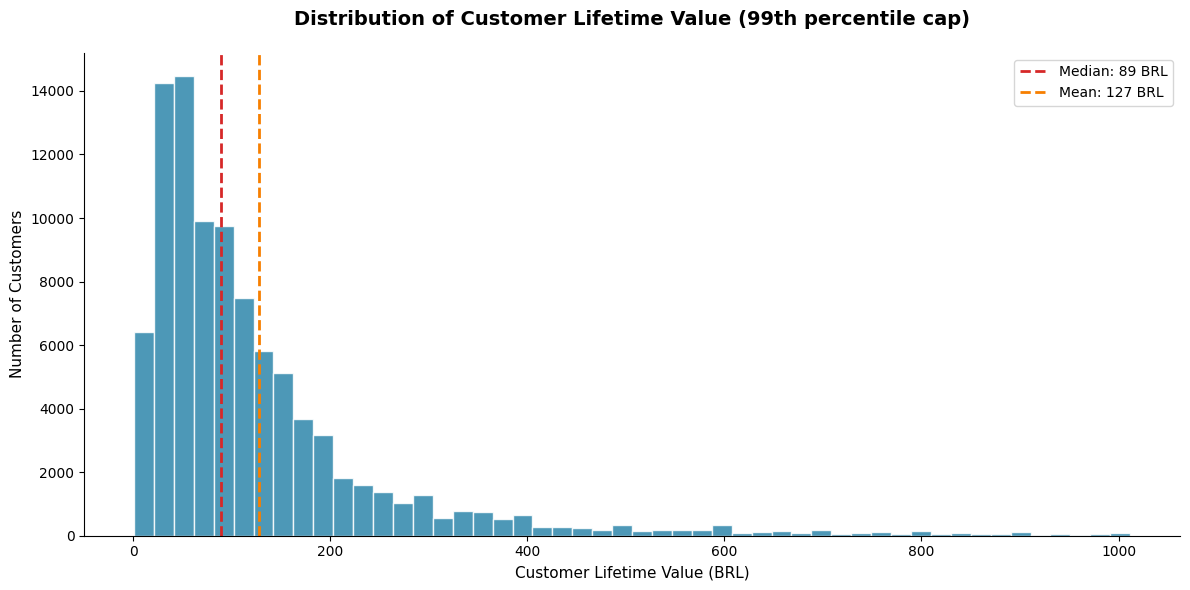

Chart saved ✅


In [15]:
# Distribution of customer lifetime value
fig, ax = plt.subplots(figsize=(12, 6))

# Cap at 99th percentile to remove extreme outliers from the visual
cutoff = customer_summary['total_revenue'].quantile(0.99)
data = customer_summary[customer_summary['total_revenue'] <= cutoff]['total_revenue']

ax.hist(data, bins=50, color='#2E86AB', edgecolor='white', alpha=0.85)
ax.axvline(data.median(), color='#D62828', linestyle='--', linewidth=2, label=f'Median: {data.median():.0f} BRL')
ax.axvline(data.mean(), color='#F77F00', linestyle='--', linewidth=2, label=f'Mean: {data.mean():.0f} BRL')

ax.set_xlabel('Customer Lifetime Value (BRL)', fontsize=11)
ax.set_ylabel('Number of Customers', fontsize=11)
ax.set_title('Distribution of Customer Lifetime Value (99th percentile cap)', fontsize=14, weight='bold', pad=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('../outputs/clv_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved ✅")

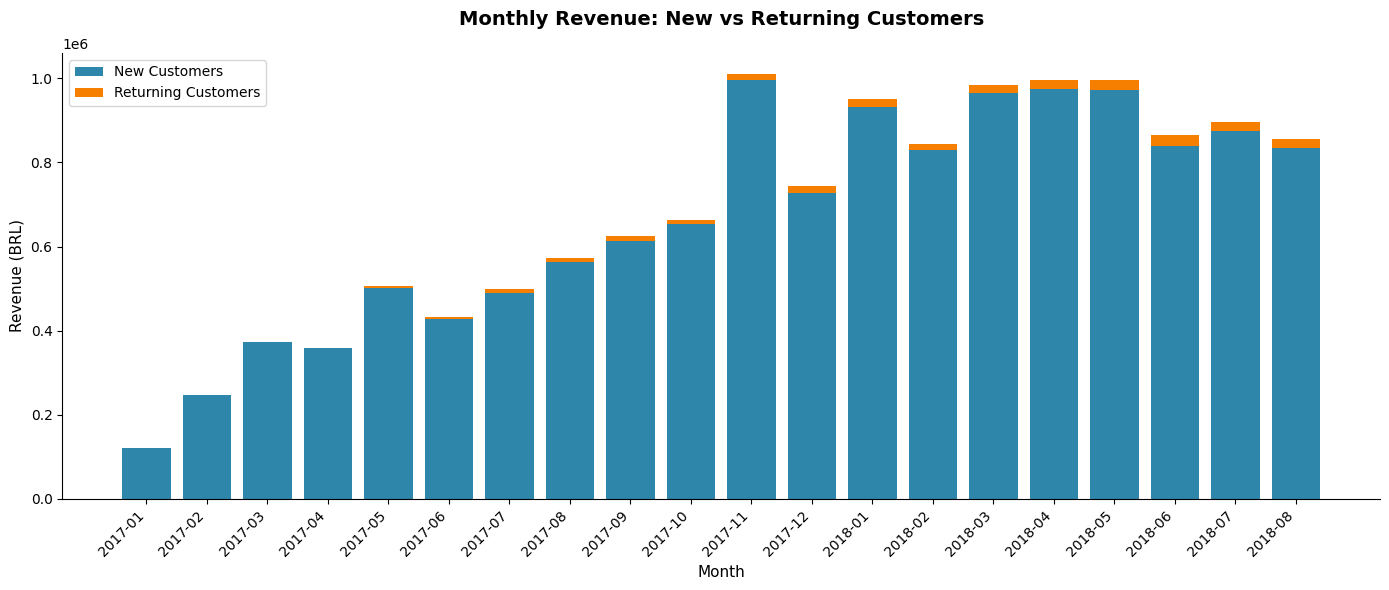

Chart saved ✅


In [16]:
# Stacked bar chart: new vs returning customer revenue by month
chart_data = significant.copy()
chart_data.index = chart_data.index.astype(str)

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(chart_data.index, chart_data['new_customer_revenue'], 
       label='New Customers', color='#2E86AB')
ax.bar(chart_data.index, chart_data['returning_customer_revenue'],
       bottom=chart_data['new_customer_revenue'],
       label='Returning Customers', color='#F77F00')

ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Revenue (BRL)', fontsize=11)
ax.set_title('Monthly Revenue: New vs Returning Customers', fontsize=14, weight='bold', pad=20)
ax.legend(loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('../outputs/new_vs_returning_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved ✅")

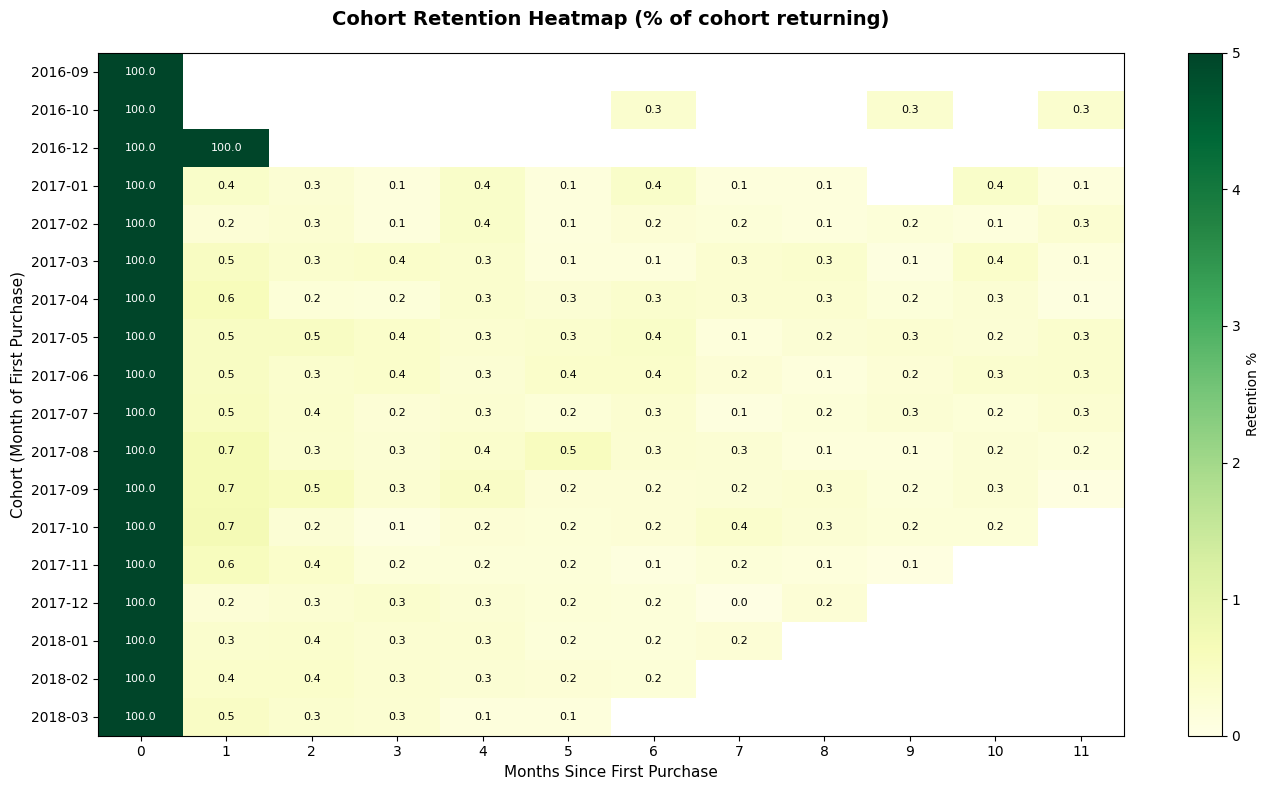

Chart saved ✅


In [17]:
# Cohort retention heatmap (the classic visualization)
import matplotlib.colors as mcolors

# Limit to first 12 periods and cohorts with enough data
display_matrix = retention_matrix.iloc[:18, :12].copy()
display_matrix.index = display_matrix.index.astype(str)

fig, ax = plt.subplots(figsize=(14, 8))

# Heatmap
im = ax.imshow(display_matrix.values, cmap='YlGn', aspect='auto', vmin=0, vmax=5)

# Label cells with values
for i in range(display_matrix.shape[0]):
    for j in range(display_matrix.shape[1]):
        value = display_matrix.iloc[i, j]
        if not pd.isna(value):
            text_color = 'white' if value > 2.5 else 'black'
            ax.text(j, i, f'{value:.1f}', ha='center', va='center', 
                   color=text_color, fontsize=8)

# Axes
ax.set_xticks(range(display_matrix.shape[1]))
ax.set_xticklabels(display_matrix.columns)
ax.set_yticks(range(display_matrix.shape[0]))
ax.set_yticklabels(display_matrix.index)
ax.set_xlabel('Months Since First Purchase', fontsize=11)
ax.set_ylabel('Cohort (Month of First Purchase)', fontsize=11)
ax.set_title('Cohort Retention Heatmap (% of cohort returning)', fontsize=14, weight='bold', pad=20)

plt.colorbar(im, ax=ax, label='Retention %')
plt.tight_layout()
plt.savefig('../outputs/cohort_retention_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved ✅")